<a href="https://colab.research.google.com/github/Jong-ho-chang/Student_Risk_Prediction/blob/main/ML%E1%84%91%E1%85%A1%E1%84%8B%E1%85%B5%E1%84%91%E1%85%B3%E1%84%85%E1%85%A1%E1%84%8B%E1%85%B5%E1%86%AB_%E1%84%8B%E1%85%B1%E1%84%92%E1%85%A5%E1%86%B7%E1%84%80%E1%85%AE%E1%86%AB%E1%84%8B%E1%85%A8%E1%84%8E%E1%85%B3%E1%86%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 학생 데이터 기반 고등학교 성적 하락 위험군 조기 예측 모델
**과제** : 교육문제해결 머신러닝 중간과제  
**알고리즘** : KNN / Random Forest  
**핵심 지표** : 위험군 재현율(Recall) 우선

---
### 파이프라인 6단계

| 셀  | 단계 | 내용 |
|-----|------|------|
| 2 | 환경 설정 | 패키지 설치·임포트·한글 폰트 |
| 3 | 문제 정형화 | 데이터 로딩·타겟 정의·피처 선정 |
| 4 | EDA | 분포·출결·통학권역 시각화 (Fig 1-2) |
| 5 | 전처리 | 분할·인코딩·스케일링·파이프라인 |
| 6 | 모델링 | Grid Search 하이퍼파라미터 탐색 |
| 7 | 평가 – 혼동행렬 | Fig 3 |
| 8 | 평가 – ROC/PR/성능 | Fig 4-5 |
| 9 | 피처 중요도 | Fig 6 |
| 10 | SHAP 분석 | Fig 7 |
| 11 | Ablation 실험 | Fig 8 |
| 12 | 임계값 분석 + 저장 | Fig 9 |

## [셀 2] 환경 설정 — 패키지 설치 · 임포트 · 한글 폰트

In [12]:
# ══════════════════════════════════════════════════════════
# [셀 2] 환경 설정
# ══════════════════════════════════════════════════════════

# ── 1. 패키지 설치 ────────────────────────────────────────
!pip install shap --quiet

# ── 2. 한글 폰트 설치 ─────────────────────────────────────
import urllib.request, os, matplotlib as mpl, matplotlib.font_manager as fm

font_url  = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
font_path = "/usr/share/fonts/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, font_path)

cache_dir = mpl.get_cachedir()
os.makedirs(cache_dir, exist_ok=True)              # 캐시 폴더 없으면 생성
for f in os.listdir(cache_dir):
    if f.startswith("fontlist"):
        os.remove(os.path.join(cache_dir, f))

fm.fontManager.addfont(font_path)
fm._load_fontmanager(try_read_cache=False)

# ── 3. 임포트 & 전역 설정 ─────────────────────────────────
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, auc,
    average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve,
    recall_score, roc_curve, f1_score, precision_score,
)
import shap
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

C_SAFE, C_RISK, C_KNN, C_RF, C_ACCENT = "#1D3557","#E76F51","#457B9D","#2A9D8F","#F4A261"

RESULT_DIR = Path("model_results")
RESULT_DIR.mkdir(exist_ok=True)

print("환경 설정 완료 ✓")
print("등록된 나눔 폰트:", [f.name for f in fm.fontManager.ttflist if "Nanum" in f.name][:3])

환경 설정 완료 ✓
등록된 나눔 폰트: ['NanumGothic']


## [셀 3] 문제 정형화 — 데이터 로딩 · 타겟 정의 · 피처 선정

### 타겟 변수 정의
`is_risk = (3학년_평균등급 − 1학년_평균등급) ≥ 0.5`
- 등급 수치가 **클수록 성취가 낮은 역방향** 척도 → 수치 증가 = 성취 하락
- 0.5등급 이상 차이 = 자연 변동을 초과하는 실질적 슬럼프

### 피처 선정
- **통학_권역** : 통학 환경·거리가 학업 지속성에 영향을 줄 수 있다는 교육학적 가설
- **1학년_평균등급** : 초기 성취 수준 (타겟 산출에도 사용 → Ablation으로 별도 검증)
- **G1_* 출결 변수** : 1학년 출결이 학업 이탈의 선행 신호라는 연구 근거
- **G2_, G3_ 제외** : 조기 예측 목적상 1학년 말 시점에 존재하지 않는 데이터

In [13]:
# ── 데이터 로딩 ──────────────────────────────────────────────────────────
# 세션에 CSV 파일을 먼저 업로드한 뒤 실행
# encoding="utf-8-sig" : 윈도우 Excel 저장 CSV의 BOM(﻿) 자동 제거
url = 'https://raw.githubusercontent.com/Jong-ho-chang/Student_Risk_Prediction/main/final_student_data_for_ml.csv'

df = pd.read_csv(url, encoding="utf-8-sig")
print(f"\n데이터 로딩 완료: {df.shape[0]}행 × {df.shape[1]}열")

# ── 타겟 변수 생성 ────────────────────────────────────────────────────────
# 등급 수치 증가 = 성취 하락이므로, 양수 차이가 실제 성적 하락을 의미
df["is_risk"] = ((df["3학년_평균등급"] - df["1학년_평균등급"]) >= 0.5).astype(int)

# ── 피처 선정 ─────────────────────────────────────────────────────────────
# G1_ 으로 시작하는 모든 출결 컬럼을 자동 수집 (향후 변수 추가 시 유지보수 용이)
g1_cols = [c for c in df.columns if c.startswith("G1_")]
FEATURE_COLS = ["통학_권역", "1학년_평균등급"] + g1_cols
CAT_COLS = ["통학_권역"]
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

X = df[FEATURE_COLS].copy()
y = df["is_risk"].copy()

# ── 기본 통계 출력 ────────────────────────────────────────────────────────
print(f"\n[타겟 분포]")
print(f"  위험군(1): {y.sum()}명  ({y.mean()*100:.1f}%)")
print(f"  안정군(0): {(~y.astype(bool)).sum()}명  ({(1-y.mean())*100:.1f}%)")
print(f"\n[독립변수 목록] ({len(FEATURE_COLS)}개)")
for c in FEATURE_COLS:
    print(f"  - {c}")
print(f"\n[수치형 변수 기술통계]")
display(df[NUM_COLS + ["is_risk"]].describe().round(3))


데이터 로딩 완료: 257행 × 30열

[타겟 분포]
  위험군(1): 80명  (31.1%)
  안정군(0): 177명  (68.9%)

[독립변수 목록] (10개)
  - 통학_권역
  - 1학년_평균등급
  - G1_미인정결과
  - G1_미인정결석
  - G1_미인정조퇴
  - G1_미인정지각
  - G1_질병결과
  - G1_질병결석
  - G1_질병조퇴
  - G1_질병지각

[수치형 변수 기술통계]


,1학년_평균등급,G1_미인정결과,G1_미인정결석,G1_미인정조퇴,G1_미인정지각,G1_질병결과,G1_질병결석,G1_질병조퇴,G1_질병지각,is_risk
count,257.000,257.000,257.000,257.000,257.000,257.000,257.000,257.000,257.000,257.000
mean,4.947,0.093,0.346,0.086,0.934,0.043,1.634,1.058,1.039,0.311
std,1.400,0.565,2.383,0.580,5.430,0.283,4.135,1.931,2.543,0.464
min,1.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,4.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,6.500,0.000,0.000,0.000,0.000,0.000,2.000,1.000,1.000,1.000
max,7.500,6.000,29.000,6.000,71.000,3.000,41.000,13.000,19.000,1.000


## [셀 4] EDA — 탐색적 데이터 분석 시각화 (Fig 1 · Fig 2)

- **Fig 1** : 타겟 클래스 분포 & 1학년 평균등급 분포 비교
- **Fig 2** : 출결 항목별 위험군/안정군 평균 & 통학 권역별 위험군 비율

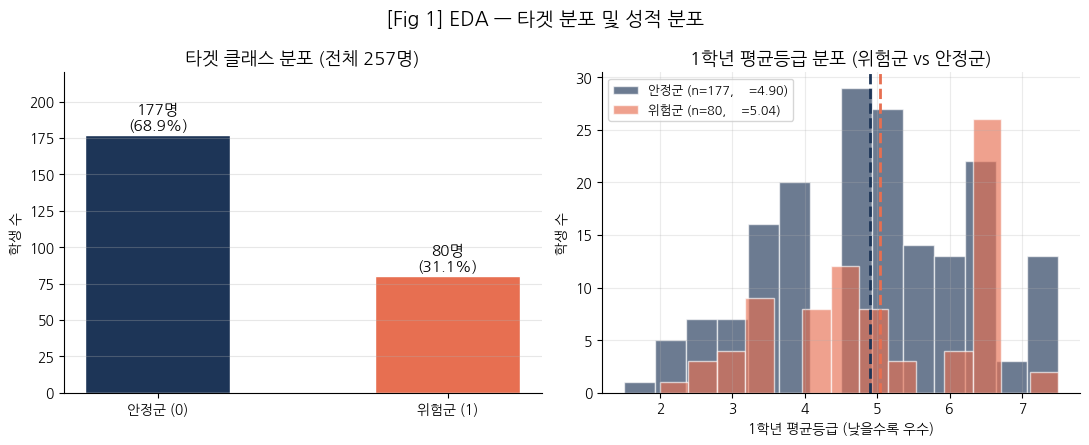

Fig 1 저장 완료 ✓


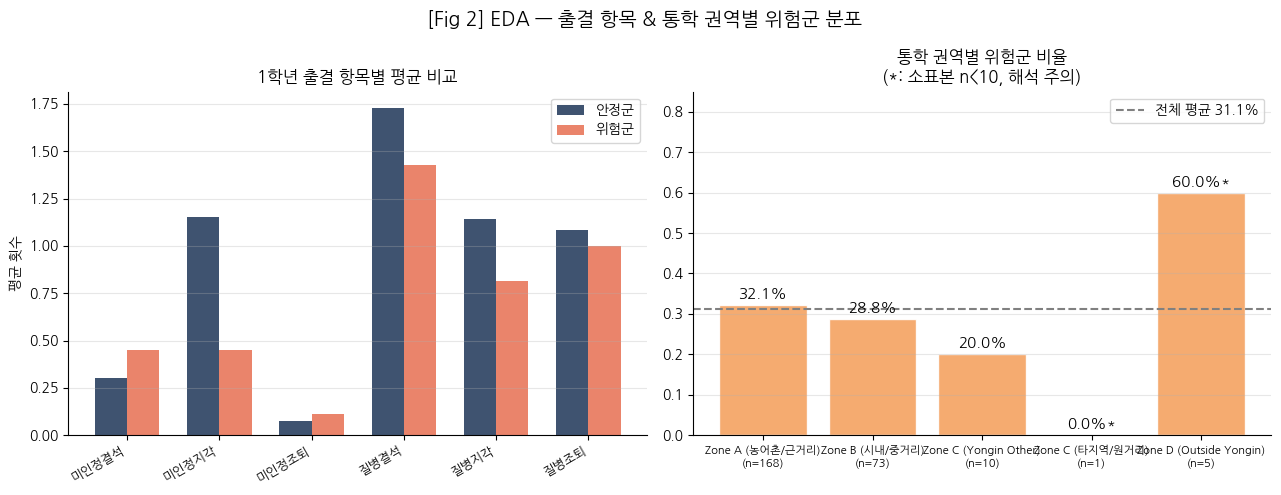

Fig 2 저장 완료 ✓


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# [Fig 1] 타겟 분포 + 1학년 평균등급 분포
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ── [Fig 1-左] 타겟 클래스 분포 막대그래프 ──────────────────────────────
risk_counts = y.value_counts().sort_index()
bars = axes[0].bar(["안정군 (0)", "위험군 (1)"],
                   risk_counts.values,
                   color=[C_SAFE, C_RISK], width=0.5, edgecolor="white")
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f"{val}명\n({val/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("타겟 클래스 분포 (전체 257명)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("학생 수"); axes[0].set_ylim(0, 220)
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

# ── [Fig 1-右] 1학년 평균등급 분포 히스토그램 ───────────────────────────
for label, color, name in [(0, C_SAFE, "안정군"), (1, C_RISK, "위험군")]:
    subset = df[df["is_risk"] == label]["1학년_평균등급"]
    axes[1].hist(subset, bins=14, alpha=0.65, color=color,
                 label=f"{name} (n={len(subset)}, μ={subset.mean():.2f})",
                 edgecolor="white")
    axes[1].axvline(subset.mean(), color=color, linestyle="--", linewidth=2)
axes[1].set_title("1학년 평균등급 분포 (위험군 vs 안정군)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("1학년 평균등급 (낮을수록 우수)")
axes[1].set_ylabel("학생 수"); axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25); axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("[Fig 1] EDA — 타겟 분포 및 성적 분포", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig1_eda_distribution.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 1 저장 완료 ✓")

# ══════════════════════════════════════════════════════════════════════════
# [Fig 2] 출결 항목별 평균 + 통학 권역별 위험군 비율
# ══════════════════════════════════════════════════════════════════════════
att_cols   = ["G1_미인정결석","G1_미인정지각","G1_미인정조퇴",
              "G1_질병결석","G1_질병지각","G1_질병조퇴"]
att_labels = ["미인정결석","미인정지각","미인정조퇴","질병결석","질병지각","질병조퇴"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── [Fig 2-左] 출결 항목별 평균 비교 ────────────────────────────────────
means0 = df[df["is_risk"]==0][att_cols].mean().values
means1 = df[df["is_risk"]==1][att_cols].mean().values
x = np.arange(len(att_cols)); w = 0.35
axes[0].bar(x - w/2, means0, w, label="안정군", color=C_SAFE, alpha=0.85)
axes[0].bar(x + w/2, means1, w, label="위험군", color=C_RISK, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(att_labels, rotation=30, ha="right", fontsize=9)
axes[0].set_ylabel("평균 횟수")
axes[0].set_title("1학년 출결 항목별 평균 비교", fontsize=12, fontweight="bold")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

# ── [Fig 2-右] 통학 권역별 위험군 비율 ──────────────────────────────────
# n<10인 권역은 소표본(*) 표시로 해석 주의 환기
zone_risk = df.groupby("통학_권역")["is_risk"].agg(["sum","count"])
zone_risk["ratio"] = zone_risk["sum"] / zone_risk["count"]
zone_names = [f"{z}\n(n={int(r['count'])})" for z, r in zone_risk.iterrows()]
bars2 = axes[1].bar(range(len(zone_risk)), zone_risk["ratio"].values,
                    color=C_ACCENT, edgecolor="white", alpha=0.9)
for bar, (_, row) in zip(bars2, zone_risk.iterrows()):
    note = f"{row['ratio']:.1%}" + ("*" if row["count"] < 10 else "")
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                 note, ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_xticks(range(len(zone_risk))); axes[1].set_xticklabels(zone_names, fontsize=8)
axes[1].axhline(y.mean(), color="gray", linestyle="--",
                linewidth=1.5, label=f"전체 평균 {y.mean():.1%}")
axes[1].set_title("통학 권역별 위험군 비율\n(*: 소표본 n<10, 해석 주의)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 0.85); axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("[Fig 2] EDA — 출결 항목 & 통학 권역별 위험군 분포",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig2_eda_attendance_zone.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 2 저장 완료 ✓")

## [셀 5] 전처리 — Train/Test 분할 · 파이프라인 구성

### 핵심 설계 결정
- **stratify=y** : 분할 후에도 위험군 비율(31%)이 유지되도록 층화 추출
- **KNN 파이프라인** : StandardScaler 필수 (거리 기반 알고리즘의 스케일 민감성)
- **RF 파이프라인** : passthrough + `class_weight='balanced'` (소수 클래스 가중치 보정)

In [15]:
# ── Train / Test 분할 ────────────────────────────────────────────────────
# test_size=0.2 : 52명 테스트, 205명 훈련
# stratify=y    : 위험군 비율을 train/test 양쪽에서 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"훈련: {len(X_train)}명  (위험군 비율 {y_train.mean():.3f})")
print(f"테스트: {len(X_test)}명  (위험군 비율 {y_test.mean():.3f})")

# ── 파이프라인 생성 함수 ──────────────────────────────────────────────────
def build_pipeline(model_type):
    # Pipeline 사용 이유:
    #   - 전처리(fit)가 항상 train 데이터 기준으로만 수행 → test leakage 구조적 방지
    #   - GridSearchCV 와 결합 시 매 fold 마다 전처리를 재학습

    cat_t = OneHotEncoder(handle_unknown="ignore")  # 미등장 범주 → 0벡터 처리
    # KNN : 거리 기반 → 표준화 필수. RF : 트리 기반 → 스케일 무관
    num_t = StandardScaler() if model_type == "knn" else "passthrough"

    preprocessor = ColumnTransformer([
        ("cat", cat_t, CAT_COLS),
        ("num", num_t, NUM_COLS),
    ])

    if model_type == "knn":
        model = KNeighborsClassifier()
    else:
        # class_weight='balanced' : 소수 클래스(위험군 31%)에
        # 177/80 ≈ 2.2배 가중치 자동 부여 → 다수 클래스 편향 보정
        model = RandomForestClassifier(random_state=42, class_weight="balanced")

    return Pipeline([("preprocessor", preprocessor), ("model", model)])

# ── 하이퍼파라미터 탐색 공간 정의 ─────────────────────────────────────────
# KNN : n_neighbors(과적합↔과소적합 트레이드오프), weights, p(거리 방식)
KNN_PARAMS = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights":     ["uniform", "distance"],
    "model__p":           [1, 2],        # p=1 맨해튼 / p=2 유클리드
}
# RF : 트리 수, 깊이, 분할 조건(과적합 제어)
RF_PARAMS = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [None, 5, 10, 15],
    "model__min_samples_split":[2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}
print("파이프라인 구성 완료 ✓")

훈련: 205명  (위험군 비율 0.312)
테스트: 52명  (위험군 비율 0.308)
파이프라인 구성 완료 ✓


## [셀 6] 모델링 — Grid Search + 5-Fold CV

`scoring='recall'` : 위험군을 놓치지 않는 것이 오탐보다 교육적으로 더 중요하므로
재현율을 최적화 기준으로 설정 → FN(실제 위험 학생 누락) 최소화 우선

In [16]:
def fit_gs(pipeline, param_grid):
    # scoring='recall' : 위험군(양성 클래스) 재현율 기준 최적 파라미터 선택
    # cv=5            : 5-Fold CV — 소규모 데이터에서 단일 split보다 안정적
    # n_jobs=-1       : 가용 CPU 코어 전체 병렬 사용
    gs = GridSearchCV(pipeline, param_grid,
                      scoring="recall", cv=5, n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    return gs

print("▶ KNN Grid Search 실행 중... (약 30초)")
knn_gs = fit_gs(build_pipeline("knn"), KNN_PARAMS)
print(f"  최적 파라미터 : {knn_gs.best_params_}")
print(f"  CV 재현율     : {knn_gs.best_score_:.4f}")

print("\n▶ RF Grid Search 실행 중... (약 60~120초)")
rf_gs  = fit_gs(build_pipeline("rf"),  RF_PARAMS)
print(f"  최적 파라미터 : {rf_gs.best_params_}")
print(f"  CV 재현율     : {rf_gs.best_score_:.4f}")

best_knn = knn_gs.best_estimator_
best_rf  = rf_gs.best_estimator_

# ── 테스트셋 예측 (이후 셀 공통 사용) ─────────────────────────────────
knn_pred = best_knn.predict(X_test)
rf_pred  = best_rf.predict(X_test)
knn_prob = best_knn.predict_proba(X_test)[:, 1]
rf_prob  = best_rf.predict_proba(X_test)[:, 1]

# ── 성능 지표 사전 계산 ────────────────────────────────────────────────
knn_acc    = accuracy_score(y_test, knn_pred)
rf_acc     = accuracy_score(y_test, rf_pred)
knn_recall = recall_score(y_test, knn_pred, pos_label=1)
rf_recall  = recall_score(y_test, rf_pred,  pos_label=1)
knn_prec   = precision_score(y_test, knn_pred, pos_label=1, zero_division=0)
rf_prec    = precision_score(y_test, rf_pred,  pos_label=1, zero_division=0)
knn_f1     = f1_score(y_test, knn_pred, pos_label=1)
rf_f1      = f1_score(y_test, rf_pred,  pos_label=1)

print("\n[KNN 분류 리포트]")
print(classification_report(y_test, knn_pred, digits=4))
print("[RF 분류 리포트]")
print(classification_report(y_test, rf_pred,  digits=4))

▶ KNN Grid Search 실행 중... (약 30초)
  최적 파라미터 : {'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}
  CV 재현율     : 0.2859

▶ RF Grid Search 실행 중... (약 60~120초)
  최적 파라미터 : {'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100}
  CV 재현율     : 0.4872

[KNN 분류 리포트]
              precision    recall  f1-score   support

           0     0.7073    0.8056    0.7532        36
           1     0.3636    0.2500    0.2963        16

    accuracy                         0.6346        52
   macro avg     0.5355    0.5278    0.5248        52
weighted avg     0.6016    0.6346    0.6126        52

[RF 분류 리포트]
              precision    recall  f1-score   support

           0     0.7097    0.6111    0.6567        36
           1     0.3333    0.4375    0.3784        16

    accuracy                         0.5577        52
   macro avg     0.5215    0.5243    0.5175        52
weighted avg     0.5939    0.5577    0.5711        

## [셀 7] 평가 — 혼동행렬 비교 (Fig 3)

| 셀 위치 | 의미 | 교육적 해석 |
|---------|------|-------------|
| TN(좌상) | 안정군→안정군 ✓ | 정확 예측 |
| FP(우상) | 안정군→위험군 ✗ | 과잉 탐지 (상담 자원 낭비 가능) |
| **FN(좌하)** | **위험군→안정군 ✗** | **최대 경계! 실제 위험 학생 누락** |
| TP(우하) | 위험군→위험군 ✓ | 조기 개입 성공 |

**재현율 = TP / (TP + FN)** → FN을 줄이는 것이 핵심

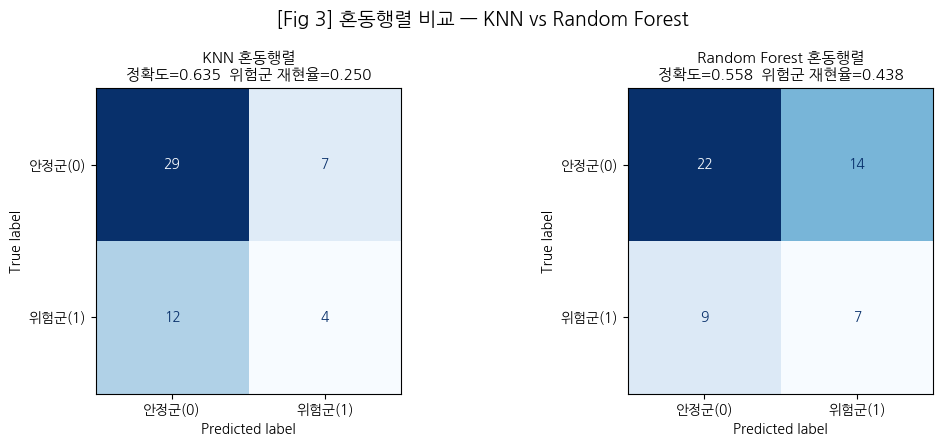

Fig 3 저장 완료 ✓


In [17]:
# ── Fig 3 : KNN / RF 혼동행렬 나란히 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in [
    (axes[0], knn_pred, "KNN"),
    (axes[1], rf_pred,  "Random Forest"),
]:
    cm   = confusion_matrix(y_test, pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["안정군(0)", "위험군(1)"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred, pos_label=1)
    ax.set_title(f"{title} 혼동행렬\n정확도={acc:.3f}  위험군 재현율={rec:.3f}",
                 fontsize=11, fontweight="bold")

fig.suptitle("[Fig 3] 혼동행렬 비교 — KNN vs Random Forest",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig3_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 3 저장 완료 ✓")

## [셀 8] 평가 — ROC 곡선 · PR 곡선 · 성능 종합 비교 (Fig 4 · 5)

- **ROC-AUC** : 0.5 = 무작위 기준. 클래스 불균형 시 낙관적 수치를 보일 수 있음
- **AP (Average Precision)** : PR 곡선 아래 넓이. 불균형 클래스 경보 품질을 더 잘 반영

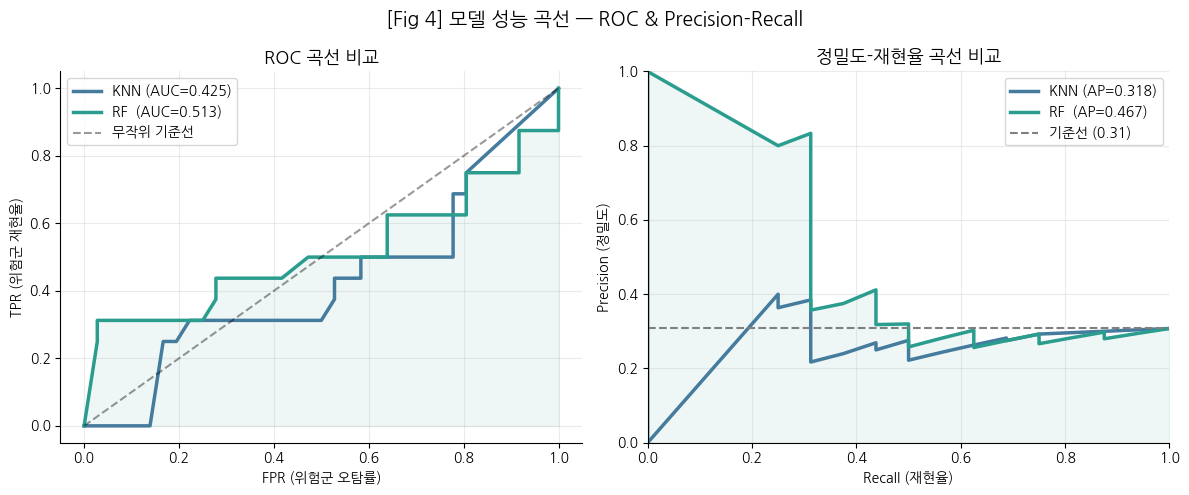

Fig 4 저장 완료 ✓


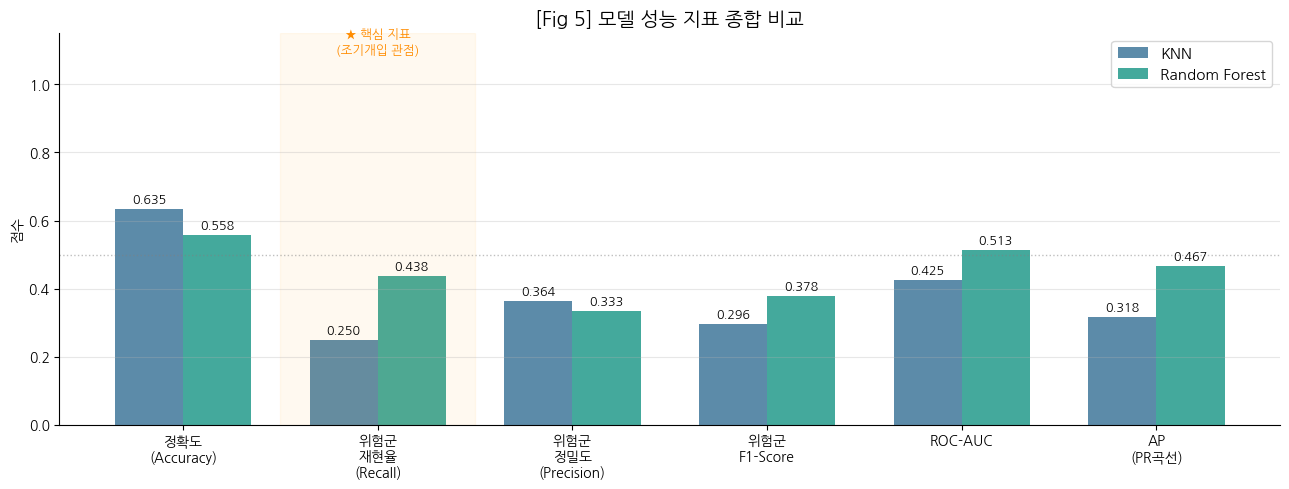

Fig 5 저장 완료 ✓

ROC-AUC : KNN=0.4253  RF=0.5130
AP      : KNN=0.3176  RF=0.4671


In [18]:
# ── ROC / PR 좌표 계산 ──────────────────────────────────────────────────
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
auc_knn = auc(fpr_knn, tpr_knn)
auc_rf  = auc(fpr_rf,  tpr_rf)

p_knn, r_knn, _ = precision_recall_curve(y_test, knn_prob)
p_rf,  r_rf,  _ = precision_recall_curve(y_test, rf_prob)
ap_knn = average_precision_score(y_test, knn_prob)
ap_rf  = average_precision_score(y_test, rf_prob)

# ── Fig 4 : ROC + PR 곡선 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_knn, tpr_knn, color=C_KNN, lw=2.5, label=f"KNN (AUC={auc_knn:.3f})")
axes[0].plot(fpr_rf,  tpr_rf,  color=C_RF,  lw=2.5, label=f"RF  (AUC={auc_rf:.3f})")
axes[0].plot([0,1],[0,1], "k--", alpha=0.4, lw=1.5, label="무작위 기준선")
axes[0].fill_between(fpr_rf, tpr_rf, alpha=0.08, color=C_RF)
axes[0].set_xlabel("FPR (위험군 오탐률)"); axes[0].set_ylabel("TPR (위험군 재현율)")
axes[0].set_title("ROC 곡선 비교", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.25)
axes[0].spines[["top","right"]].set_visible(False)

baseline = y_test.mean()    # 무작위 분류기의 정밀도 기댓값 ≈ 위험군 비율
axes[1].plot(r_knn, p_knn, color=C_KNN, lw=2.5, label=f"KNN (AP={ap_knn:.3f})")
axes[1].plot(r_rf,  p_rf,  color=C_RF,  lw=2.5, label=f"RF  (AP={ap_rf:.3f})")
axes[1].axhline(baseline, color="gray", linestyle="--",
                lw=1.5, label=f"기준선 ({baseline:.2f})")
axes[1].fill_between(r_rf, p_rf, alpha=0.08, color=C_RF)
axes[1].set_xlabel("Recall (재현율)"); axes[1].set_ylabel("Precision (정밀도)")
axes[1].set_title("정밀도-재현율 곡선 비교", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.25)
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("[Fig 4] 모델 성능 곡선 — ROC & Precision-Recall",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig4_roc_pr_curves.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 4 저장 완료 ✓")

# ── Fig 5 : 성능 지표 종합 비교 막대그래프 ──────────────────────────────
metrics  = ["정확도\n(Accuracy)","위험군\n재현율\n(Recall)","위험군\n정밀도\n(Precision)",
            "위험군\nF1-Score","ROC-AUC","AP\n(PR곡선)"]
knn_vals = [knn_acc, knn_recall, knn_prec, knn_f1, auc_knn, ap_knn]
rf_vals  = [rf_acc,  rf_recall,  rf_prec,  rf_f1,  auc_rf,  ap_rf]

x = np.arange(len(metrics)); width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, knn_vals, width, label="KNN", color=C_KNN, alpha=0.88)
b2 = ax.bar(x + width/2, rf_vals,  width, label="Random Forest", color=C_RF,  alpha=0.88)
for bars, vals in [(b1, knn_vals), (b2, rf_vals)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
# 재현율 열(인덱스 1) 강조 : 조기 개입의 핵심 지표임을 시각적으로 표시
ax.axvspan(0.5, 1.5, alpha=0.06, color="orange")
ax.text(1, 1.09, "★ 핵심 지표\n(조기개입 관점)",
        ha="center", fontsize=9, color="darkorange", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.15); ax.set_ylabel("점수")
ax.set_title("[Fig 5] 모델 성능 지표 종합 비교", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.axhline(0.5, color="gray", linestyle=":", lw=1, alpha=0.5)
ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig5_performance_summary.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 5 저장 완료 ✓")
print(f"\nROC-AUC : KNN={auc_knn:.4f}  RF={auc_rf:.4f}")
print(f"AP      : KNN={ap_knn:.4f}  RF={ap_rf:.4f}")

## [셀 9] 모델 해석 — RF 피처 중요도 (Fig 6)

- 불순도(Gini) 감소량 기준. **방향(+/−) 없음** → SHAP과 병행 해석 필요
- `preprocessor.get_feature_names_out()` : One-Hot 분해 후 실제 컬럼명 반환

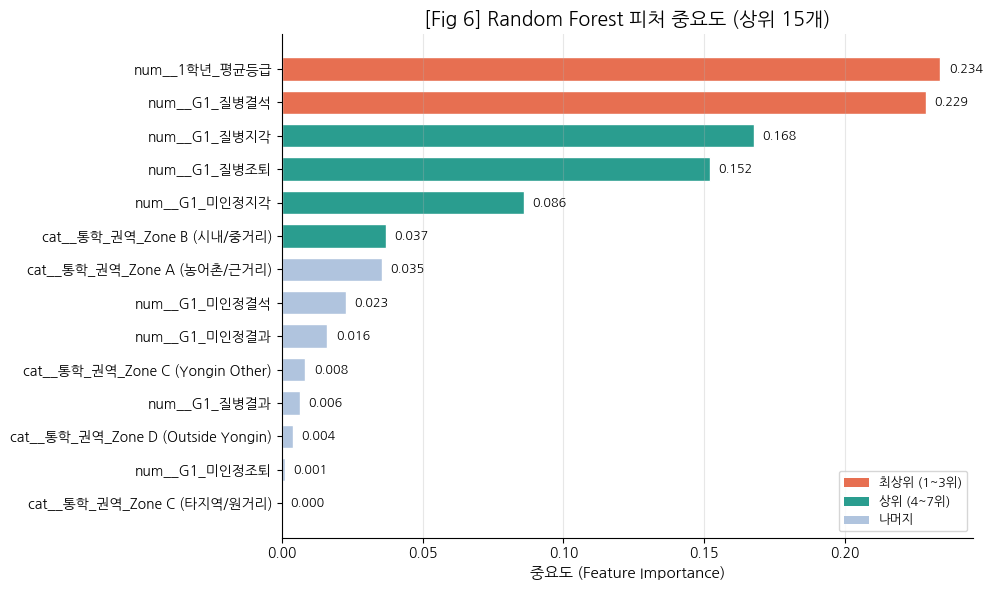

Fig 6 저장 완료 ✓

[상위 8개 변수]
                    feature  importance
              num__1학년_평균등급    0.233876
               num__G1_질병결석    0.228784
               num__G1_질병지각    0.167609
               num__G1_질병조퇴    0.152159
              num__G1_미인정지각    0.086033
 cat__통학_권역_Zone B (시내/중거리)    0.037056
cat__통학_권역_Zone A (농어촌/근거리)    0.035490
              num__G1_미인정결석    0.022736


In [19]:
# ── RF 피처 중요도 추출 ──────────────────────────────────────────────────
preprocessor_rf = best_rf.named_steps["preprocessor"]
model_rf        = best_rf.named_steps["model"]

feature_names = preprocessor_rf.get_feature_names_out()
importances   = model_rf.feature_importances_

imp_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
          .sort_values("importance", ascending=False)
          .reset_index(drop=True))

TOP_N  = 15
top_df = imp_df.head(TOP_N).copy()
# 색상 구분: 상위 3개(강조) / 4~7위 / 나머지
colors = ["#E76F51"]*3 + ["#2A9D8F"]*4 + ["#B0C4DE"]*(TOP_N-7)

# ── Fig 6 ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_df["feature"][::-1], top_df["importance"][::-1],
               color=colors[::-1], edgecolor="white", height=0.7)
for bar, val in zip(bars, top_df["importance"][::-1]):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("중요도 (Feature Importance)", fontsize=11)
ax.set_title(f"[Fig 6] Random Forest 피처 중요도 (상위 {TOP_N}개)",
             fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(facecolor="#E76F51", label="최상위 (1~3위)"),
    mpatches.Patch(facecolor="#2A9D8F", label="상위 (4~7위)"),
    mpatches.Patch(facecolor="#B0C4DE", label="나머지"),
], loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig6_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 6 저장 완료 ✓")
print("\n[상위 8개 변수]")
print(imp_df.head(8).to_string(index=False))

## [셀 10] 모델 해석 — SHAP 분석 (Fig 7)

- **기여도 막대** : 각 변수의 평균 |SHAP| → 위험 예측 기여 크기
- **Dependence Plot** : G1 질병조퇴 횟수 증가 → SHAP 값 변화 → **임계점 탐색**

base_value (위험군 사전 확률) = 0.5044


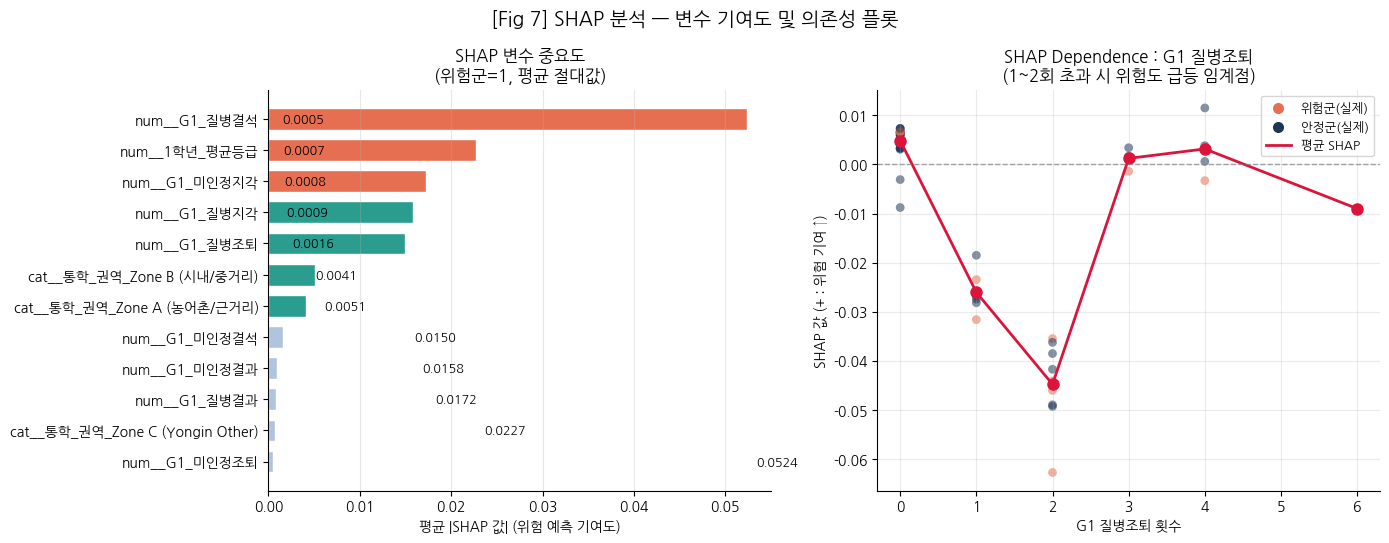

Fig 7 저장 완료 ✓


In [20]:
# ── 전처리 후 배열 변환 (SHAP은 원시 배열 필요) ────────────────────────
X_t = preprocessor_rf.transform(X_test)
if hasattr(X_t, "toarray"):
    X_t = X_t.toarray()          # 희소행렬 → 밀집 배열
X_shap_df = pd.DataFrame(X_t, columns=feature_names, index=X_test.index)

# TreeExplainer : 트리 기반 모델 전용, 정확하고 빠른 SHAP 계산
explainer   = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_shap_df)
sv          = np.asarray(shap_values)

# 이진분류 RF → (n, features, 2) : 클래스 1(위험군) 슬라이싱
if sv.ndim == 3 and sv.shape[-1] == 2:
    class1_vals = sv[:, :, 1]
elif isinstance(shap_values, list):
    class1_vals = np.asarray(shap_values[1])
else:
    class1_vals = sv

ev         = explainer.expected_value
base_value = float(ev[1]) if hasattr(ev, "__len__") and len(ev) > 1 else float(ev)
print(f"base_value (위험군 사전 확률) = {base_value:.4f}")

# ── Fig 7 : SHAP 기여도 막대 + Dependence Plot ──────────────────────────
shap_mean = np.abs(class1_vals).mean(axis=0)
shap_df   = (pd.DataFrame({"feature": feature_names, "mean_shap": shap_mean})
             .sort_values("mean_shap", ascending=False)
             .head(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── [Fig 7-左] SHAP 기여도 막대 ────────────────────────────────────────
shap_colors = ["#E76F51"]*3 + ["#2A9D8F"]*4 + ["#B0C4DE"]*5
axes[0].barh(shap_df["feature"][::-1], shap_df["mean_shap"][::-1],
             color=shap_colors[::-1], height=0.7, edgecolor="white")
for i, (_, row) in enumerate(shap_df[::-1].iterrows()):
    axes[0].text(row["mean_shap"]+0.001,
                 len(shap_df)-1-list(shap_df.index[::-1]).index(_)+0.0,
                 f"{row['mean_shap']:.4f}", va="center", fontsize=9)
axes[0].set_xlabel("평균 |SHAP 값| (위험 예측 기여도)")
axes[0].set_title("SHAP 변수 중요도\n(위험군=1, 평균 절대값)",
                  fontsize=12, fontweight="bold")
axes[0].grid(axis="x", alpha=0.3); axes[0].spines[["top","right"]].set_visible(False)

# ── [Fig 7-右] Dependence Plot : G1 질병조퇴 ───────────────────────────
dep_list = [c for c in X_shap_df.columns if "질병조퇴" in c and "G1" in c]
if dep_list:
    col     = dep_list[0]
    col_idx = list(X_shap_df.columns).index(col)
    x_vals  = X_shap_df[col].to_numpy(dtype=float)
    y_shap  = class1_vals[:, col_idx].astype(float)
    pt_colors = [C_RISK if v == 1 else C_SAFE for v in y_test.values]
    axes[1].scatter(x_vals, y_shap, alpha=0.55, s=40, c=pt_colors, edgecolors="none")
    uniq = np.unique(x_vals[~np.isnan(x_vals)])
    if uniq.size <= 20:
        means = [float(np.mean(y_shap[x_vals == u])) for u in uniq]
        axes[1].plot(uniq, means, "o-", color="crimson", lw=2, ms=8, label="값별 평균 SHAP")
    axes[1].axhline(0, color="gray", linestyle="--", lw=1, alpha=0.7)
    axes[1].set_xlabel("G1 질병조퇴 횟수")
    axes[1].set_ylabel("SHAP 값 (+ : 위험 기여 ↑)")
    axes[1].set_title("SHAP Dependence : G1 질병조퇴\n(1~2회 초과 시 위험도 급등 임계점)",
                      fontsize=12, fontweight="bold")
    axes[1].legend(handles=[
        mlines.Line2D([0],[0],marker="o",color="w",markerfacecolor=C_RISK,ms=9,label="위험군(실제)"),
        mlines.Line2D([0],[0],marker="o",color="w",markerfacecolor=C_SAFE,ms=9,label="안정군(실제)"),
        mlines.Line2D([0],[0],color="crimson",lw=2,label="평균 SHAP"),
    ], fontsize=9)
    axes[1].grid(alpha=0.25); axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("[Fig 7] SHAP 분석 — 변수 기여도 및 의존성 플롯",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig7_shap_analysis.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 7 저장 완료 ✓")

## [셀 11] Ablation 실험 — 1학년 평균등급 제거 효과 (Fig 8)

**설계** : 타겟 정의(3학년-1학년 차이)는 유지, **입력(X)에서만** 성적 변수 제거  
→ "출결·통학만으로도 위험 패턴을 포착할 수 있는가?"에 대한 실증 실험

▶ KNN Ablation Grid Search...
▶ RF  Ablation Grid Search...

KNN : 정확도 0.6346→0.6731  재현율 0.2500→0.0625
RF  : 정확도 0.5577→0.4808   재현율 0.4375→0.5000


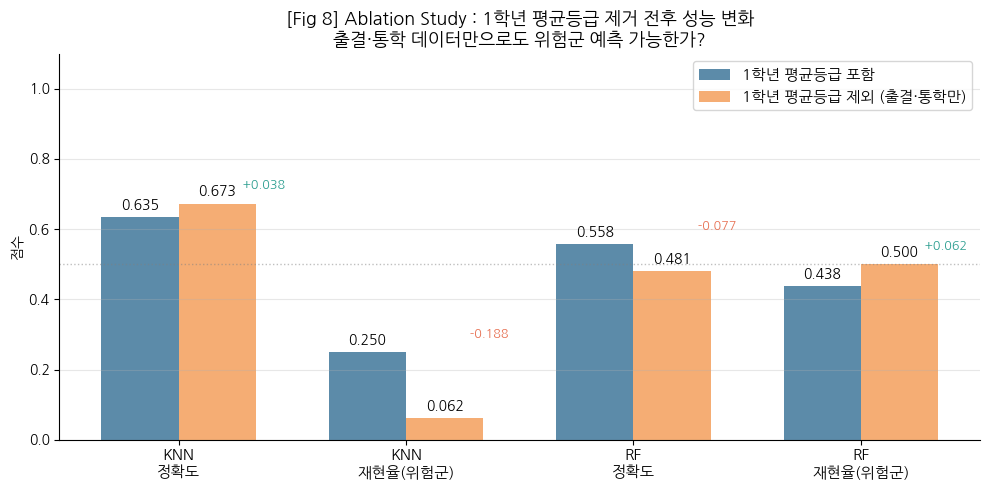

Fig 8 저장 완료 ✓


In [21]:
# ── Ablation : 성적 변수 제거 후 재학습 ────────────────────────────────
NUM_AB  = [c for c in NUM_COLS if c != "1학년_평균등급"]
X_tr_ab = X_train.drop(columns=["1학년_평균등급"])
X_te_ab = X_test.drop(columns=["1학년_평균등급"])

def build_pipeline_ab(model_type):
    cat_t = OneHotEncoder(handle_unknown="ignore")
    num_t = StandardScaler() if model_type == "knn" else "passthrough"
    pre   = ColumnTransformer([("cat", cat_t, CAT_COLS), ("num", num_t, NUM_AB)])
    model = (KNeighborsClassifier() if model_type == "knn"
             else RandomForestClassifier(random_state=42, class_weight="balanced"))
    return Pipeline([("preprocessor", pre), ("model", model)])

print("▶ KNN Ablation Grid Search...")
knn_ab = GridSearchCV(build_pipeline_ab("knn"), KNN_PARAMS, scoring="recall", cv=5, n_jobs=-1)
knn_ab.fit(X_tr_ab, y_train)
knn_pred_ab = knn_ab.best_estimator_.predict(X_te_ab)
knn_acc_ab  = accuracy_score(y_test, knn_pred_ab)
knn_rec_ab  = recall_score(y_test, knn_pred_ab, pos_label=1)

print("▶ RF  Ablation Grid Search...")
rf_ab  = GridSearchCV(build_pipeline_ab("rf"),  RF_PARAMS,  scoring="recall", cv=5, n_jobs=-1)
rf_ab.fit(X_tr_ab, y_train)
rf_pred_ab  = rf_ab.best_estimator_.predict(X_te_ab)
rf_acc_ab   = accuracy_score(y_test, rf_pred_ab)
rf_rec_ab   = recall_score(y_test, rf_pred_ab, pos_label=1)

print(f"\nKNN : 정확도 {knn_acc:.4f}→{knn_acc_ab:.4f}  재현율 {knn_recall:.4f}→{knn_rec_ab:.4f}")
print(f"RF  : 정확도 {rf_acc:.4f}→{rf_acc_ab:.4f}   재현율 {rf_recall:.4f}→{rf_rec_ab:.4f}")

# ── Fig 8 ─────────────────────────────────────────────────────────────────
labels = ["KNN\n정확도","KNN\n재현율(위험군)","RF\n정확도","RF\n재현율(위험군)"]
full_v = [knn_acc, knn_recall, rf_acc, rf_recall]
ab_v   = [knn_acc_ab, knn_rec_ab, rf_acc_ab, rf_rec_ab]
x = np.arange(len(labels)); width = 0.34

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, full_v, width, label="1학년 평균등급 포함", color=C_KNN, alpha=0.88)
ax.bar(x + width/2, ab_v,   width, label="1학년 평균등급 제외 (출결·통학만)",
       color=C_ACCENT, alpha=0.88)
for fv, av, xi in zip(full_v, ab_v, x):
    ax.text(xi - width/2, fv + 0.015, f"{fv:.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
    ax.text(xi + width/2, av + 0.015, f"{av:.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
    delta = av - fv
    color = C_RF if delta > 0 else C_RISK
    ax.annotate(f"Δ{delta:+.3f}",
                xy=(xi + width/2 + 0.06, max(fv, av) + 0.04),
                ha="left", fontsize=9, color=color, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel("점수")
ax.set_title("[Fig 8] Ablation Study : 1학년 평균등급 제거 전후 성능 변화\n"
             "출결·통학 데이터만으로도 위험군 예측 가능한가?",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.axhline(0.5, color="gray", linestyle=":", lw=1, alpha=0.5)
ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig8_ablation_study.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 8 저장 완료 ✓")

## [셀 12] 임계값 분석 & 전체 결과 저장 (Fig 9)

- **임계값 ↓** : 재현율 ↑, 정밀도 ↓ (더 많이 탐지, 오탐도 증가)  
- **임계값 ↑** : 재현율 ↓, 정밀도 ↑ (탐지 수 감소, 정확도 향상)  
- **교육 현장 제안** : 0.4 기준으로 상담 대상 우선 선정 → 교사 전문 판단으로 최종 확인

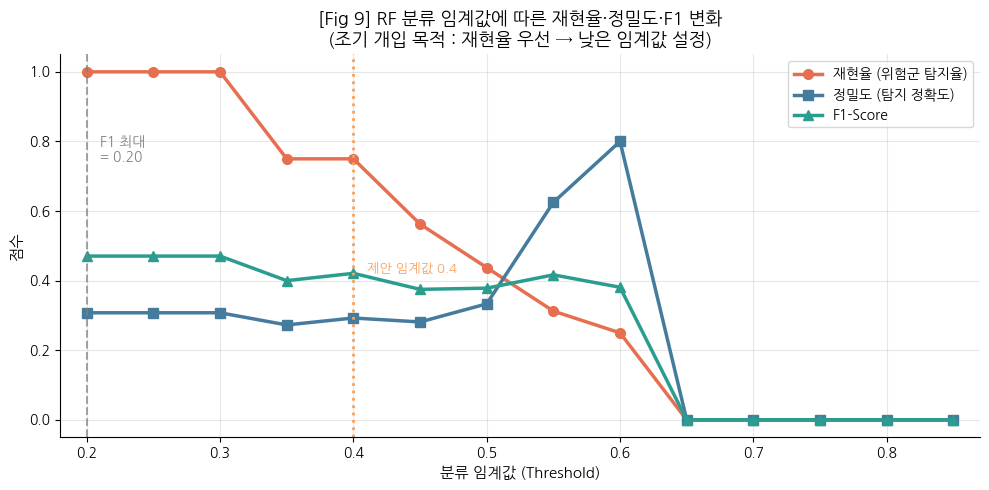

Fig 9 저장 완료 ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


전체 결과물 ZIP 다운로드 시작 ✓  (model_results.zip)
  - 그래프 9종 (fig1~fig9)
  - 결과 리포트 (model_report.txt)


In [22]:
# ── 임계값 변화에 따른 재현율·정밀도·F1 계산 ────────────────────────────
thresholds = np.arange(0.20, 0.86, 0.05)
recalls, precisions, f1s = [], [], []
for t in thresholds:
    pred_t = (rf_prob >= t).astype(int)
    recalls.append(recall_score(y_test, pred_t, pos_label=1, zero_division=0))
    precisions.append(precision_score(y_test, pred_t, pos_label=1, zero_division=0))
    f1s.append(f1_score(y_test, pred_t, pos_label=1, zero_division=0))
best_f1_idx = int(np.argmax(f1s))

# ── Fig 9 ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recalls,    "o-", color=C_RISK, lw=2.5, ms=7, label="재현율 (위험군 탐지율)")
ax.plot(thresholds, precisions, "s-", color=C_KNN,  lw=2.5, ms=7, label="정밀도 (탐지 정확도)")
ax.plot(thresholds, f1s,        "^-", color=C_RF,   lw=2.5, ms=7, label="F1-Score")
ax.axvline(thresholds[best_f1_idx], color="gray", linestyle="--", lw=1.5, alpha=0.7)
ax.text(thresholds[best_f1_idx]+0.01, 0.74,
        f"F1 최대\n= {thresholds[best_f1_idx]:.2f}", fontsize=10, color="gray")
ax.axvline(0.4, color=C_ACCENT, linestyle=":", lw=2)
ax.text(0.41, 0.42, "제안 임계값 0.4", fontsize=9.5, color=C_ACCENT, fontweight="bold")
ax.set_xlabel("분류 임계값 (Threshold)", fontsize=11)
ax.set_ylabel("점수", fontsize=11)
ax.set_title("[Fig 9] RF 분류 임계값에 따른 재현율·정밀도·F1 변화\n"
             "(조기 개입 목적 : 재현율 우선 → 낮은 임계값 설정)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False); ax.set_xlim(0.18, 0.87)
fig.tight_layout()
fig.savefig(RESULT_DIR / "fig9_threshold_analysis.png", dpi=160, bbox_inches="tight")
plt.show(); print("Fig 9 저장 완료 ✓")

# ── 최종 결과 리포트 텍스트 ──────────────────────────────────────────────
report = "\n".join([
    "="*60, "학생 데이터 기반 성적 하락 위험군 조기 예측 — 최종 결과 리포트",
    "="*60,
    f"\n[데이터]  전체 {len(df)}명 | 위험군 {y.sum()}명({y.mean()*100:.1f}%) | 안정군 {(1-y).sum()}명",
    f"\n[최적 하이퍼파라미터]",
    f"  KNN : {knn_gs.best_params_}  (CV 재현율 {knn_gs.best_score_:.4f})",
    f"  RF  : {rf_gs.best_params_}  (CV 재현율 {rf_gs.best_score_:.4f})",
    f"\n[테스트 성능]",
    f"  {'지표':<20} {'KNN':>8} {'RF':>8}",
    f"  {'정확도':<20} {knn_acc:>8.4f} {rf_acc:>8.4f}",
    f"  {'위험군 재현율':<20} {knn_recall:>8.4f} {rf_recall:>8.4f}",
    f"  {'위험군 정밀도':<20} {knn_prec:>8.4f} {rf_prec:>8.4f}",
    f"  {'위험군 F1':<20} {knn_f1:>8.4f} {rf_f1:>8.4f}",
    f"  {'ROC-AUC':<20} {auc_knn:>8.4f} {auc_rf:>8.4f}",
    f"  {'AP (PR곡선)':<20} {ap_knn:>8.4f} {ap_rf:>8.4f}",
    f"\n[Ablation : 1학년 평균등급 제거]",
    f"  KNN 재현율 {knn_recall:.4f} → {knn_rec_ab:.4f}",
    f"  RF  재현율 {rf_recall:.4f} → {rf_rec_ab:.4f}",
    "="*60,
])
(RESULT_DIR / "model_report.txt").write_text(report, encoding="utf-8")

# ── 전체 결과물 ZIP 다운로드 ─────────────────────────────────────────────
import zipfile
zip_path = "model_results.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in sorted(RESULT_DIR.iterdir()):
        zf.write(f, f.name)
from google.colab import files
files.download(zip_path)
print(f"\n전체 결과물 ZIP 다운로드 시작 ✓  ({zip_path})")
print(f"  - 그래프 9종 (fig1~fig9)")
print(f"  - 결과 리포트 (model_report.txt)")